In [1]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive", force_remount=True)

DATASET_ROOT = Path("/content/drive/MyDrive/unet_dataset_mt2023_v2/shards")
RUN_ROOT     = Path("/content/drive/MyDrive/unet_runs/unet_mt2023_v2_run1")

print("DATASET_ROOT:", DATASET_ROOT)
print("RUN_ROOT    :", RUN_ROOT)

assert DATASET_ROOT.exists(), f"não achei dataset: {DATASET_ROOT}"
assert RUN_ROOT.exists(), f"não achei run: {RUN_ROOT}"

for s in ["train","val","test"]:
    p = DATASET_ROOT / s
    assert p.exists(), f"não achei split: {p}"

BEST_PT = RUN_ROOT / "checkpoints" / "best.pt"
LAST_PT = RUN_ROOT / "checkpoints" / "last.pt"
HIST    = RUN_ROOT / "logs" / "history.jsonl"

print("best.pt existe?", BEST_PT.exists(), "| sizeMB:", (BEST_PT.stat().st_size/1024**2) if BEST_PT.exists() else None)
print("last.pt existe?", LAST_PT.exists(), "| sizeMB:", (LAST_PT.stat().st_size/1024**2) if LAST_PT.exists() else None)
print("history.jsonl existe?", HIST.exists())

Mounted at /content/drive
DATASET_ROOT: /content/drive/MyDrive/unet_dataset_mt2023_v2/shards
RUN_ROOT    : /content/drive/MyDrive/unet_runs/unet_mt2023_v2_run1
best.pt existe? True | sizeMB: 88.99758815765381
last.pt existe? True | sizeMB: 88.99758815765381
history.jsonl existe? True


In [2]:
import os, json, math, time, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [3]:
def count_shards(split: str):
    shards = sorted((DATASET_ROOT / split).glob("*.npz"))
    return shards

for s in ["train","val","test"]:
    shards = count_shards(s)
    print(f"{s}: {len(shards)} shards | exemplo:", shards[0].name if shards else None)

assert len(count_shards("train")) > 0
assert len(count_shards("val")) > 0
assert len(count_shards("test")) > 0

train: 94 shards | exemplo: shard_0000.npz
val: 19 shards | exemplo: shard_0000.npz
test: 19 shards | exemplo: shard_0000.npz


In [4]:
from collections import OrderedDict

PATCH = 256
C = 21
SCALE_U16 = 10000.0     # X veio uint16 escalado por 10000
BATCH_SIZE = 8
NUM_WORKERS = 0         # estabilidade (Drive). se estiver em GPU e estável, tente 2
PIN_MEMORY = bool(device.type == "cuda")

class NPZCache:
    """cache simples LRU para reduzir I/O do Drive"""
    def __init__(self, max_open=2):
        self.max_open = max_open
        self.cache = OrderedDict()

    def get(self, path: Path):
        key = str(path)
        if key in self.cache:
            self.cache.move_to_end(key)
            return self.cache[key]
        z = np.load(path, allow_pickle=True)
        self.cache[key] = z
        if len(self.cache) > self.max_open:
            _, old = self.cache.popitem(last=False)
            try: old.close()
            except: pass
        return z

    def close_all(self):
        for _, z in self.cache.items():
            try: z.close()
            except: pass
        self.cache.clear()

class ShardDataset(Dataset):
    """
    shards .npz: X (N,H,W,C) uint16, Y (N,H,W) uint8, meta (N,) object (dict/None)
    """
    def __init__(self, split_dir: Path, scale_u16: float = 10000.0, cache_open=2):
        self.split_dir = Path(split_dir)
        self.scale_u16 = float(scale_u16)
        self.shards = sorted(self.split_dir.glob("*.npz"))
        assert len(self.shards) > 0, f"sem shards em {self.split_dir}"

        self.cache = NPZCache(max_open=cache_open)

        self.index = []
        for si, p in enumerate(self.shards):
            with np.load(p, allow_pickle=True) as z:
                n = int(z["X"].shape[0])
            self.index.extend([(si, i) for i in range(n)])

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        si, pi = self.index[idx]
        p = self.shards[si]
        z = self.cache.get(p)

        X = z["X"][pi]          # (H,W,C) uint16
        Y = z["Y"][pi]          # (H,W) uint8

        meta = None
        if "meta" in z.files:
            m = z["meta"][pi]
            # pode vir dict direto, ou numpy object; tratar ambos
            if isinstance(m, dict) or m is None:
                meta = m
            else:
                try:
                    meta = m.item()
                except:
                    meta = m

        X = (X.astype(np.float32) / self.scale_u16)     # [0,1]
        X = np.transpose(X, (2, 0, 1))                  # (C,H,W)

        return torch.from_numpy(X), torch.from_numpy(Y.astype(np.uint8)), meta

def collate(batch):
    X = torch.stack([b[0] for b in batch], dim=0)
    Y = torch.stack([b[1] for b in batch], dim=0)
    meta = [b[2] for b in batch]
    return X, Y, meta

def make_loader(split: str, shuffle: bool):
    ds = ShardDataset(DATASET_ROOT / split, scale_u16=SCALE_U16, cache_open=2)
    dl = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
        collate_fn=collate
    )
    return ds, dl

train_ds, train_loader = make_loader("train", shuffle=True)
val_ds,   val_loader   = make_loader("val",   shuffle=False)
test_ds,  test_loader  = make_loader("test",  shuffle=False)

print("len(train_ds):", len(train_ds), "batches:", len(train_loader))
print("len(val_ds):  ", len(val_ds),   "batches:", len(val_loader))
print("len(test_ds): ", len(test_ds),  "batches:", len(test_loader))

# sanity 1 batch
X, Y, meta = next(iter(train_loader))
print("X:", tuple(X.shape), X.dtype, "min/max:", float(X.min()), float(X.max()))
print("Y:", tuple(Y.shape), Y.dtype)
u, c = torch.unique(Y, return_counts=True)
print("unique(Y):", dict(zip(u.tolist(), c.tolist())))
print("meta[0]:", meta[0])

len(train_ds): 3000 batches: 375
len(val_ds):   600 batches: 75
len(test_ds):  600 batches: 75
X: (8, 21, 256, 256) torch.float32 min/max: 0.0 1.0
Y: (8, 256, 256) torch.uint8
unique(Y): {0: 17219, 1: 1366, 255: 505703}
meta[0]: {'tile': 'unet_mt_2023_mosaic_x-58p00_y-15p00.tif', 'key': 'x-58p00_y-15p00', 'split': 'train', 'kind': 'neg', 'x0': 1349, 'y0': 2148}


In [5]:
assert BEST_PT.exists(), "best.pt não encontrado"

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_ch=21, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(base*4, base*8)
        self.pool4 = nn.MaxPool2d(2)

        self.bott = ConvBlock(base*8, base*16)

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = ConvBlock(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.head = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bott(self.pool4(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.head(d1)   # logits (B,1,H,W)

ckpt = torch.load(BEST_PT, map_location=device)
sd = ckpt["model"]

model = UNet(in_ch=21, base=32).to(device)
model.load_state_dict(sd, strict=True)
model.eval()

print("OK ✅ loaded strict=True")
print("ckpt epoch:", ckpt.get("epoch"), "| best_val:", ckpt.get("best_val"), "| val_loss:", ckpt.get("val_loss"))

OK ✅ loaded strict=True
ckpt epoch: 7 | best_val: 0.05278628298624729 | val_loss: 0.05278628298624729


In [6]:
@torch.no_grad()
def eval_loader(model, loader, thr=0.5):
    model.eval()
    eps = 1e-9

    TP = FP = FN = TN = 0
    total_valid = 0
    total_loss = 0.0
    n_batches = 0

    bce = nn.BCEWithLogitsLoss(reduction="none")

    for X, Y, _ in loader:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)   # uint8

        logits = model(X).squeeze(1)          # (B,H,W)
        valid = (Y != 255)
        y = (Y == 1).float()                  # milho=1, não-milho=0

        # loss apenas em pixels válidos
        loss_map = bce(logits, y)
        loss = (loss_map[valid]).mean()
        total_loss += float(loss.item())
        n_batches += 1

        prob = torch.sigmoid(logits)
        pred = (prob >= thr)

        y_true = (Y == 1) & valid
        y_false = (Y == 0) & valid

        TP += int((pred & y_true).sum().item())
        FP += int((pred & y_false).sum().item())
        FN += int((~pred & y_true).sum().item())
        TN += int((~pred & y_false).sum().item())
        total_valid += int(valid.sum().item())

    precision = TP / (TP + FP + eps)
    recall    = TP / (TP + FN + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou_pos   = TP / (TP + FP + FN + eps)
    acc       = (TP + TN) / (TP + TN + FP + FN + eps)

    return {
        "thr": thr,
        "loss": total_loss / max(n_batches, 1),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou_pos": iou_pos,
        "acc_valid": acc,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "valid_pixels": total_valid
    }

In [7]:
ths = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in ths:
    m = eval_loader(model, val_loader, thr=t)
    rows.append(m)
    print(f"thr={t:.2f} | val loss={m['loss']:.4f} iou={m['iou_pos']:.4f} f1={m['f1']:.4f} p={m['precision']:.4f} r={m['recall']:.4f} acc={m['acc_valid']:.4f}")

best = max(rows, key=lambda d: d["iou_pos"])
BEST_THR = best["thr"]
print("\nBEST_THR (by IoU):", BEST_THR, "| metrics:", {k: round(best[k],4) for k in ["loss","iou_pos","f1","precision","recall","acc_valid"]})

thr=0.30 | val loss=0.0532 iou=0.9625 f1=0.9809 p=0.9629 r=0.9995 acc=0.9837
thr=0.40 | val loss=0.0532 iou=0.9634 f1=0.9814 p=0.9644 r=0.9990 acc=0.9842
thr=0.50 | val loss=0.0532 iou=0.9640 f1=0.9817 p=0.9654 r=0.9985 acc=0.9844
thr=0.60 | val loss=0.0532 iou=0.9641 f1=0.9817 p=0.9661 r=0.9978 acc=0.9845
thr=0.70 | val loss=0.0532 iou=0.9636 f1=0.9815 p=0.9665 r=0.9969 acc=0.9843

BEST_THR (by IoU): 0.6 | metrics: {'loss': 0.0532, 'iou_pos': 0.9641, 'f1': 0.9817, 'precision': 0.9661, 'recall': 0.9978, 'acc_valid': 0.9845}


In [8]:
thr = float(globals().get("BEST_THR", 0.5))
test_metrics = eval_loader(model, test_loader, thr=thr)

print("TEST metrics:")
for k in ["thr","loss","iou_pos","f1","precision","recall","acc_valid","TP","FP","FN","TN","valid_pixels"]:
    v = test_metrics[k]
    print(f"  {k}: {v if isinstance(v,(int,str)) else float(v):.6f}" if isinstance(v,float) else f"  {k}: {v}")

# salva json no run
OUT_EVAL = RUN_ROOT / "eval"
OUT_EVAL.mkdir(parents=True, exist_ok=True)

(OUT_EVAL / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")
print("salvo em:", OUT_EVAL / "test_metrics.json")

TEST metrics:
  thr: 0.600000
  loss: 0.048753
  iou_pos: 0.977841
  f1: 0.988797
  precision: 0.990181
  recall: 0.987416
  acc_valid: 0.989884
  TP: 600203
  FP: 5952
  FN: 7649
  TN: 730645
  valid_pixels: 1344449
salvo em: /content/drive/MyDrive/unet_runs/unet_mt2023_v2_run1/eval/test_metrics.json


TEST samples:


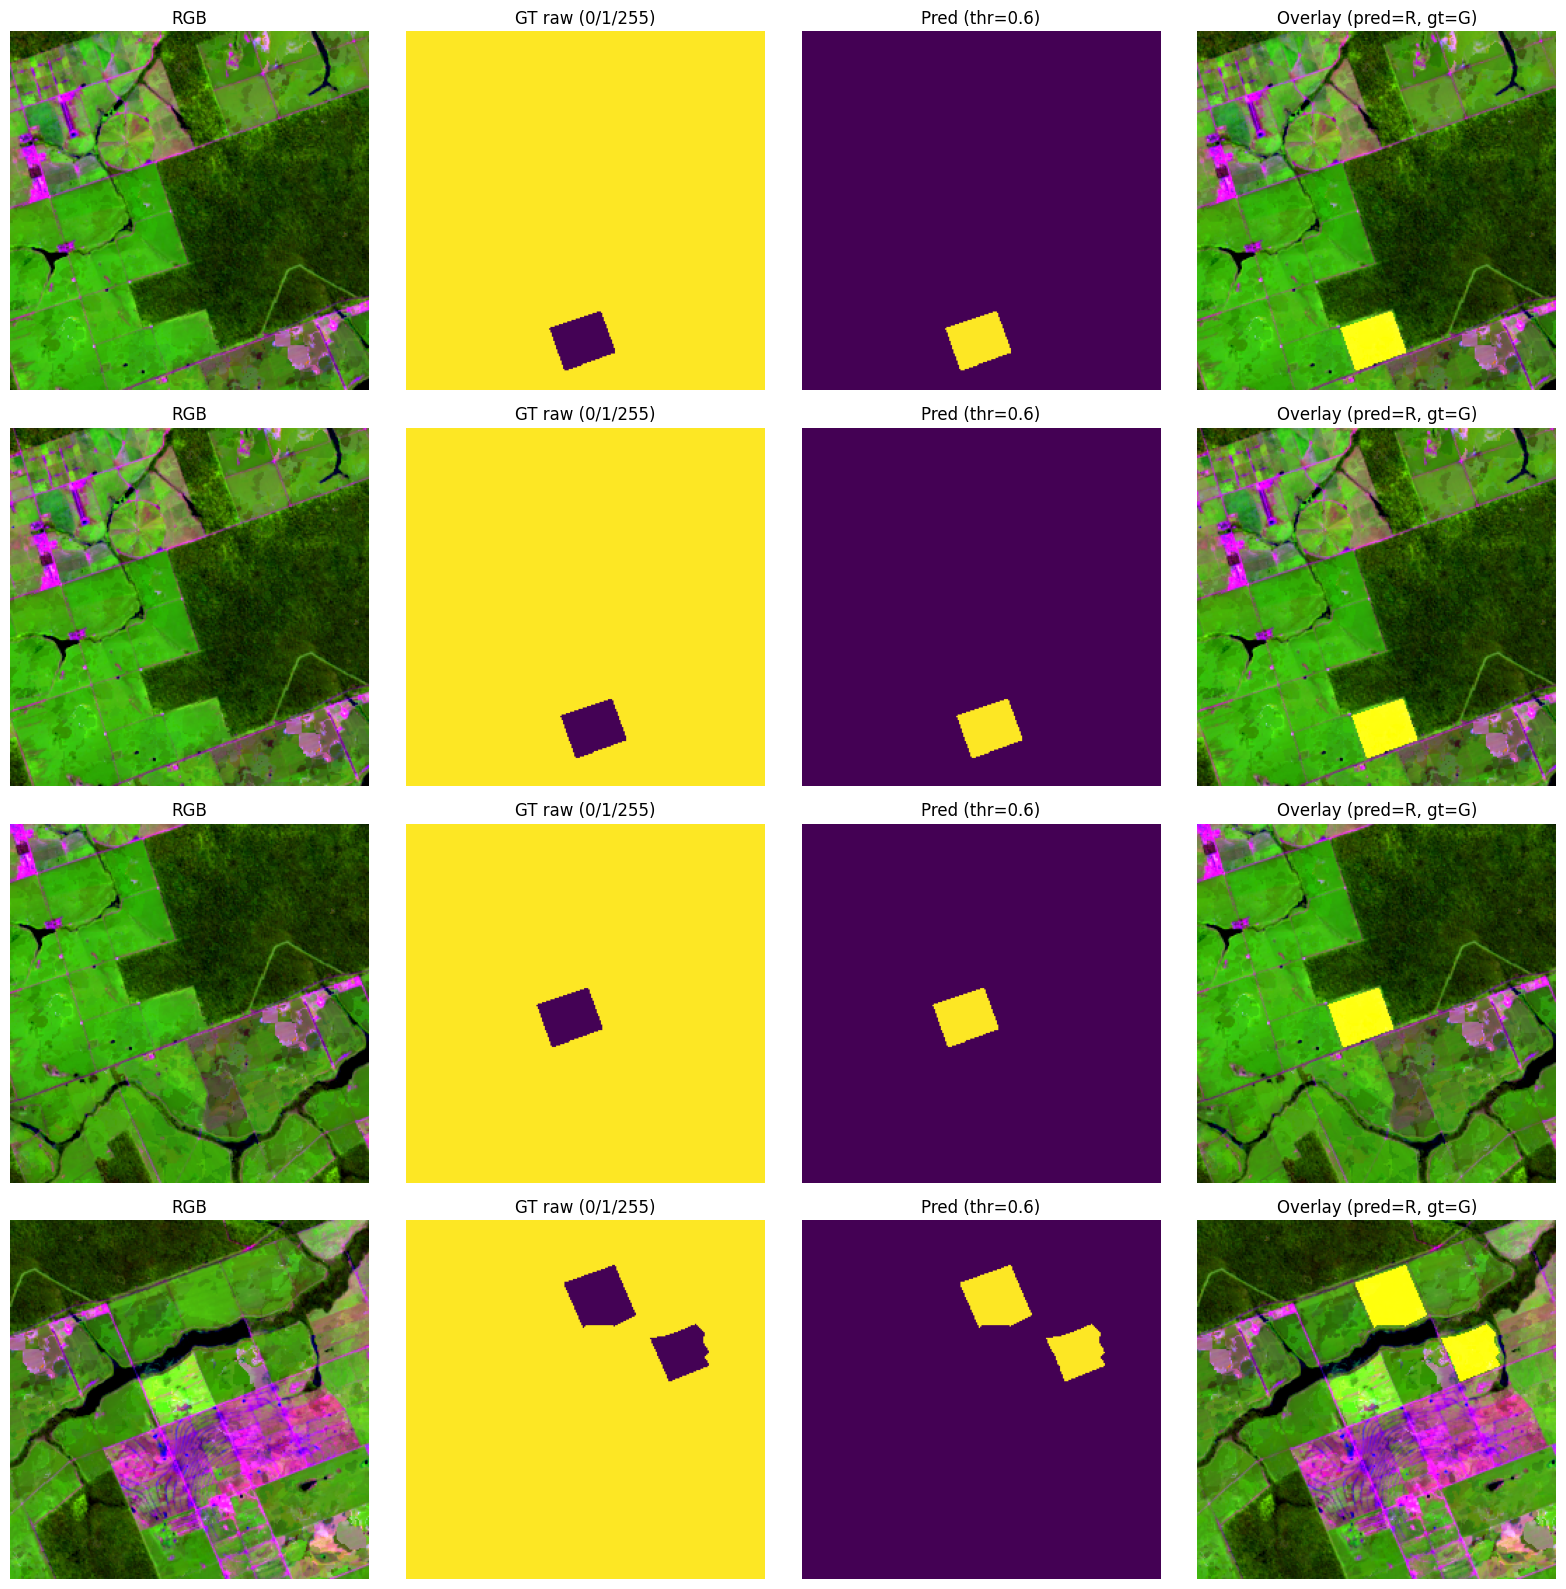

In [9]:
import matplotlib.pyplot as plt

# bandas para um RGB “agradável” no mosaico (você pode mudar)
# aqui uso: NIR_median, SWIR1_median, RED_median (igual você vinha usando)
# precisamos dos índices no X (21 bandas). Assumimos ordem do seu ee.Image.cat.
# BLUE_median(0), BLUE_p20(1), BLUE_p80(2),
# GREEN_median(3), GREEN_p20(4), GREEN_p80(5),
# RED_median(6), RED_p20(7), RED_p80(8),
# NIR_median(9), NIR_p20(10), NIR_p80(11),
# SWIR1_median(12), SWIR1_p20(13), SWIR1_p80(14),
# SWIR2_median(15), SWIR2_p20(16), SWIR2_p80(17),
# EVI2_median(18), EVI2_p20(19), EVI2_p80(20)

IDX_R = 12  # SWIR1_median
IDX_G = 9   # NIR_median
IDX_B = 6   # RED_median

thr = float(globals().get("BEST_THR", 0.5))

@torch.no_grad()
def show_batch(split_loader, n=4):
    model.eval()
    X, Y, meta = next(iter(split_loader))
    Xd = X.to(device)
    logits = model(Xd).squeeze(1).cpu()
    prob = torch.sigmoid(logits)
    pred = (prob >= thr).byte()

    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    pred = pred.cpu().numpy()

    n = min(n, X.shape[0])

    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1:
        axes = np.expand_dims(axes, 0)

    for i in range(n):
        rgb = np.stack([X[i, IDX_R], X[i, IDX_G], X[i, IDX_B]], axis=-1)
        rgb = np.clip(rgb, 0, 1)

        gt = Y[i]
        valid = (gt != 255)
        gt_bin = np.zeros_like(gt, dtype=np.uint8)
        gt_bin[valid] = (gt[valid] == 1).astype(np.uint8)

        pr = pred[i]
        pr = pr * valid.astype(np.uint8)

        overlay = rgb.copy()
        # vermelho = pred; verde = gt
        overlay[..., 0] = np.clip(overlay[..., 0] + 0.8*pr, 0, 1)
        overlay[..., 1] = np.clip(overlay[..., 1] + 0.8*gt_bin, 0, 1)

        axes[i,0].imshow(rgb);      axes[i,0].set_title("RGB"); axes[i,0].axis("off")
        axes[i,1].imshow(gt, vmin=0, vmax=255); axes[i,1].set_title("GT raw (0/1/255)"); axes[i,1].axis("off")
        axes[i,2].imshow(pr, vmin=0, vmax=1);   axes[i,2].set_title(f"Pred (thr={thr})"); axes[i,2].axis("off")
        axes[i,3].imshow(overlay);  axes[i,3].set_title("Overlay (pred=R, gt=G)"); axes[i,3].axis("off")

    plt.tight_layout()
    plt.show()

print("TEST samples:")
show_batch(test_loader, n=4)

history rows: 25
Index(['epoch', 'train_loss', 'val_loss', 'train_iou', 'val_iou', 'train_f1',
       'val_f1', 'lr'],
      dtype='object')


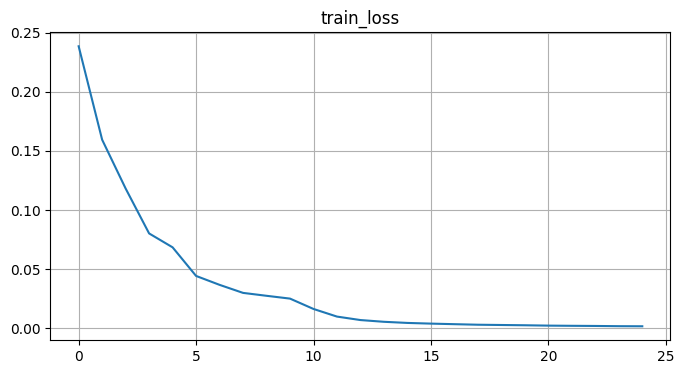

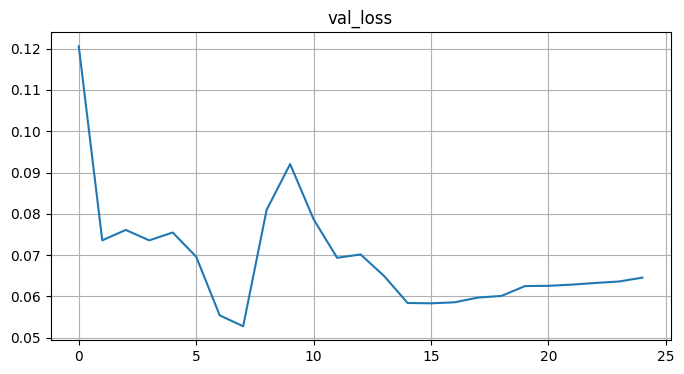

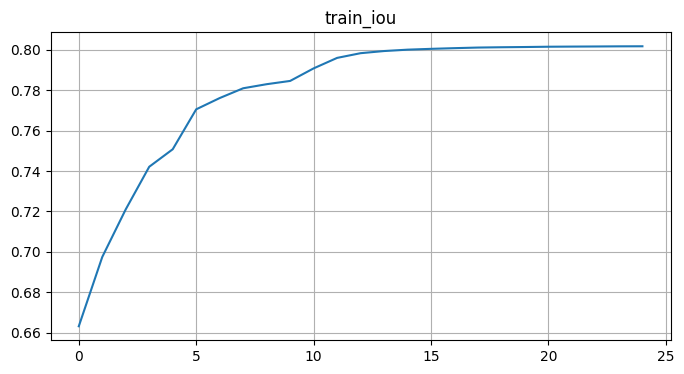

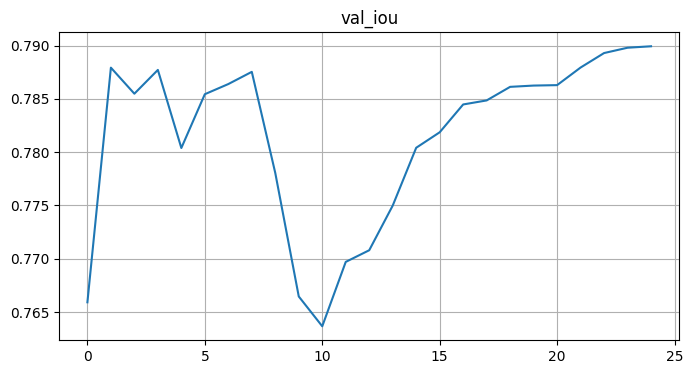

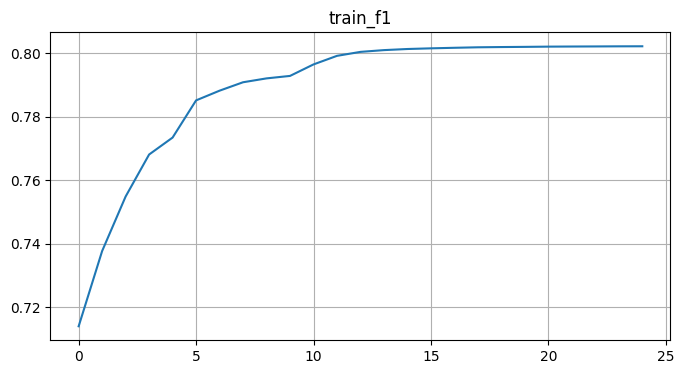

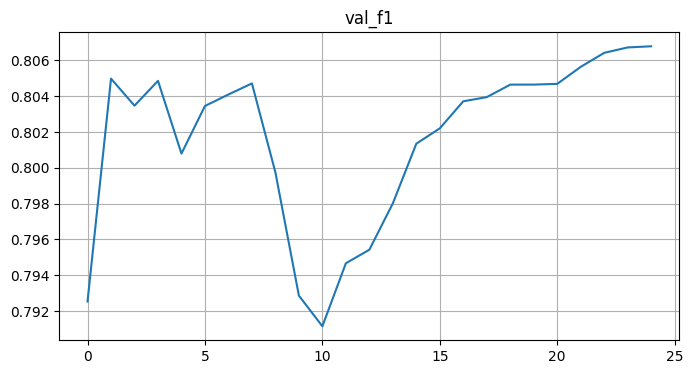

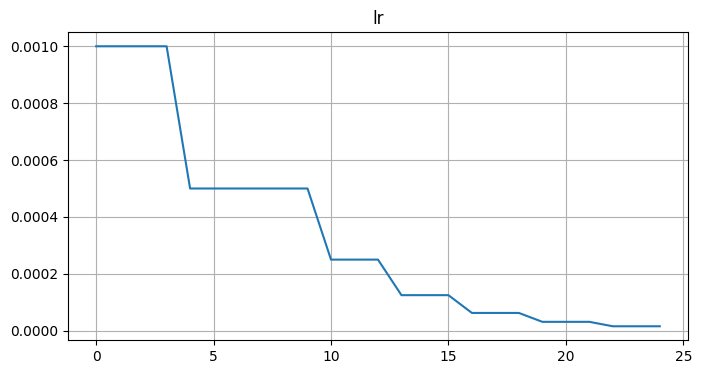

In [10]:
import pandas as pd

if HIST.exists():
    rows = []
    with HIST.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except:
                pass

    df = pd.DataFrame(rows)
    print("history rows:", len(df))
    print(df.columns)

    # tenta plotar loss/iou/f1 se existirem
    import matplotlib.pyplot as plt

    def safe_plot(col):
        if col in df.columns:
            plt.figure(figsize=(8,4))
            plt.plot(df[col].values)
            plt.title(col)
            plt.grid(True)
            plt.show()

    for c in ["train_loss","val_loss","train_iou","val_iou","train_f1","val_f1","lr"]:
        safe_plot(c)
else:
    print("history.jsonl não existe em:", HIST)